In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation across all genes

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)

mac = 20

config_path = "/home/dnanexus/ukbgym/config_olink.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",-1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
…,…,…,…,…
"""regulatory_nondir""","""abexp_min""","""#00A99D""","""AbExp min""",1
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1
"""regulatory""","""fz_delta_score""","""salmon""","""Most deviant Fz score""",1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
min_range = -100
max_range = +0

variant_class = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

abs_phenotypes = False

anno_wide = (
    anno
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

tss,loftee_hc,gpn_score,promoterai,delta_score,am_pathogenicity,gpn_star_llr_calibrated_mean,cadd_raw,abexp_min,promoterai_abs,pangolin_score,strand,verphylop,absplice_dna_max,id,esmscoremissense,dist_to_tss,score_pai3d,gene_name,absplice2_max,region,gene_length
i64,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32,str,f32,i64,f32,str,f32,str,i64
177984303,0,-8.17,0.0,0.03,0.748,-7.272596,5.289581,-0.140443,0.0,0.04,"""-1""",9.96,0.011,"""chr1:177946510:G:A""",-7.779,37793,0.793948,"""SEC16B""",0.002355,"""ENSG00000120341""",60349
177984303,0,-7.59,0.0,0.0,0.2993,-5.665048,2.316195,-0.112486,0.0,0.01,"""-1""",-0.001,0.003,"""chr1:177960806:T:A""",-2.685,23497,0.49196,"""SEC16B""",0.000854,"""ENSG00000120341""",60349
177984303,0,-7.46,0.0,0.12,0.2027,-7.034506,5.857862,-0.126506,0.0,0.03,"""-1""",10.03,0.005,"""chr1:177942016:G:A""",-7.18,42287,0.795879,"""SEC16B""",0.000982,"""ENSG00000120341""",60349
177984303,0,-5.11,0.0,0.02,0.1094,-3.375457,2.075818,-0.064856,0.0,0.0,"""-1""",1.39,0.003,"""chr1:177940660:C:G""",-3.431,43643,0.48799,"""SEC16B""",0.000308,"""ENSG00000120341""",60349
177984303,0,-2.96,0.0,0.0,0.1337,-1.954383,2.176489,-0.014604,0.0,0.0,"""-1""",0.474,0.001,"""chr1:177937390:A:C""",-3.63,46913,0.52926,"""SEC16B""",0.000033,"""ENSG00000120341""",60349
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
40694773,0,-7.46,0.0,0.0,0.2858,-8.260452,3.637395,-0.059222,0.0,0.02,"""1""",0.16,0.003,"""chr15:40698837:C:T""",-8.502,4064,0.797106,"""RAD51""",0.002202,"""ENSG00000051180""",37568
68560336,0,-7.29,0.0,0.0,0.2283,-5.042427,4.087614,-0.015385,0.0,0.02,"""1""",4.533,0.001,"""chr10:68572606:C:G""",-3.645,12270,0.576393,"""TET1""",0.000034,"""ENSG00000138336""",134152
40694773,0,-11.61,0.0,0.0,0.8616,-11.46476,4.322935,-0.070655,0.0,0.0,"""1""",8.618,0.003,"""chr15:40728740:A:C""",-4.857,33967,0.827792,"""RAD51""",0.000348,"""ENSG00000051180""",37568


In [5]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno_wide
    
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr1:177946510:G:A""","""ENSG00000120341""","""cadd_raw""",5.289581
"""chr1:177960806:T:A""","""ENSG00000120341""","""cadd_raw""",2.316195
"""chr1:177942016:G:A""","""ENSG00000120341""","""cadd_raw""",5.857862
"""chr1:177940660:C:G""","""ENSG00000120341""","""cadd_raw""",2.075818
"""chr1:177937390:A:C""","""ENSG00000120341""","""cadd_raw""",2.176489
…,…,…,…
"""chr15:40698837:C:T""","""ENSG00000051180""","""verphylop""",0.16
"""chr10:68572606:C:G""","""ENSG00000138336""","""verphylop""",4.533
"""chr15:40728740:A:C""","""ENSG00000051180""","""verphylop""",8.618


In [6]:
# --- 1. Lazily prepare the filter keys ---

# Read Olink RVAT significant
olnk_subset = pl.read_csv('/home/dnanexus/data_dir/olink_genebass1e6_371genes.tsv', separator='\t')
olnk_rvat_genes = (
    pl.read_csv('/home/dnanexus/data_dir/olink/olink_rvat_fdr.tsv', separator='\t')
    .filter(pl.col('is_plof_significant_fdr')==True)
    .filter(pl.col('n_pos')>=10)
    .filter(pl.col('gene').is_in(olnk_subset['region']))['gene'].to_list()
)
olnk_rvat_genes = [g+'_olink' for g in olnk_rvat_genes]


# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('phenotype').is_in(olnk_rvat_genes)) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
    .rename({
        'phenotype': 'olink_prot',
    })
    .collect(engine='streaming')
)

gp_corr_df

/tmp/ipykernel_487682/3707805390.py:9: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,olink_prot,annotation,n_variants,correlation
str,str,str,u64,f64
"""ENSG00000164867""","""ENSG00000164867_olink""","""gpn_score""",191,0.195862
"""ENSG00000110934""","""ENSG00000110934_olink""","""am_pathogenicity""",69,-0.20437
"""ENSG00000142192""","""ENSG00000142192_olink""","""verphylop""",109,0.133213
"""ENSG00000171174""","""ENSG00000171174_olink""","""esmscoremissense""",47,0.549954
"""ENSG00000123454""","""ENSG00000123454_olink""","""am_pathogenicity""",130,-0.170346
…,…,…,…,…
"""ENSG00000119535""","""ENSG00000119535_olink""","""gpn_score""",117,-0.131646
"""ENSG00000104320""","""ENSG00000104320_olink""","""gpn_score""",91,0.043575
"""ENSG00000134853""","""ENSG00000134853_olink""","""verphylop""",136,-0.02999


In [7]:
gp_corr_df = (
    gp_corr_df
    .select(['region', 'olink_prot', 'annotation', 'n_variants', 'correlation'])
    .join(
        anno_config_df,
        on='annotation'
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('annotation_dir')
    )
)
gp_corr_df#['annotation'].value_counts(sort=True)

region,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta
str,str,str,u64,f64,str,str,str,i64,f64
"""ENSG00000164867""","""ENSG00000164867_olink""","""gpn_score""",191,0.195862,"""conservation""","""#942c80""","""GPN-MSA""",1,0.195862
"""ENSG00000110934""","""ENSG00000110934_olink""","""am_pathogenicity""",69,-0.20437,"""missense""","""#feb72d""","""AlphaMissense""",-1,0.20437
"""ENSG00000142192""","""ENSG00000142192_olink""","""verphylop""",109,0.133213,"""conservation""","""#942c80""","""Vertebrate PhyloP""",-1,-0.133213
"""ENSG00000171174""","""ENSG00000171174_olink""","""esmscoremissense""",47,0.549954,"""missense""","""#feb72d""","""ESM1v""",1,0.549954
"""ENSG00000123454""","""ENSG00000123454_olink""","""am_pathogenicity""",130,-0.170346,"""missense""","""#feb72d""","""AlphaMissense""",-1,0.170346
…,…,…,…,…,…,…,…,…,…
"""ENSG00000119535""","""ENSG00000119535_olink""","""gpn_score""",117,-0.131646,"""conservation""","""#942c80""","""GPN-MSA""",1,-0.131646
"""ENSG00000104320""","""ENSG00000104320_olink""","""gpn_score""",91,0.043575,"""conservation""","""#942c80""","""GPN-MSA""",1,0.043575
"""ENSG00000134853""","""ENSG00000134853_olink""","""verphylop""",136,-0.02999,"""conservation""","""#942c80""","""Vertebrate PhyloP""",-1,0.02999


In [8]:
consistent_genes = (
    gp_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == gp_corr_df['annotation'].n_unique())
)

filt_corr_df = gp_corr_df.join(consistent_genes, on=['region'], how='inner')
# filt_corr_df = gp_corr_df.filter(pl.col("n_variants") > 10)  # Filter for groups with more than 10 variants
filt_corr_df = gp_corr_df.filter(pl.col("n_variants") > 100)
filt_corr_df.sort('corr_beta', descending=True)

region,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta
str,str,str,u64,f64,str,str,str,i64,f64
"""ENSG00000187800""","""ENSG00000187800_olink""","""score_pai3d""",169,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",-1,NaN
"""ENSG00000198670""","""ENSG00000198670_olink""","""am_pathogenicity""",249,NaN,"""missense""","""#feb72d""","""AlphaMissense""",-1,NaN
"""ENSG00000133805""","""ENSG00000133805_olink""","""score_pai3d""",125,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",-1,NaN
"""ENSG00000099331""","""ENSG00000099331_olink""","""score_pai3d""",365,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",-1,NaN
"""ENSG00000160255""","""ENSG00000160255_olink""","""score_pai3d""",158,NaN,"""missense""","""#feb72d""","""PrimateAI-3D""",-1,NaN
…,…,…,…,…,…,…,…,…,…
"""ENSG00000080031""","""ENSG00000080031_olink""","""gpn_star_llr_calibrated_mean""",198,-0.139501,"""conservation""","""#942c80""","""GPN-Star""",1,-0.139501
"""ENSG00000080031""","""ENSG00000080031_olink""","""esmscoremissense""",198,-0.160092,"""missense""","""#feb72d""","""ESM1v""",1,-0.160092
"""ENSG00000103126""","""ENSG00000103126_olink""","""cadd_raw""",157,0.163466,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",-1,-0.163466


In [9]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 2
Inconsistent (region, phenotype) pairs: 0


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 9 rows containing non-finite values.


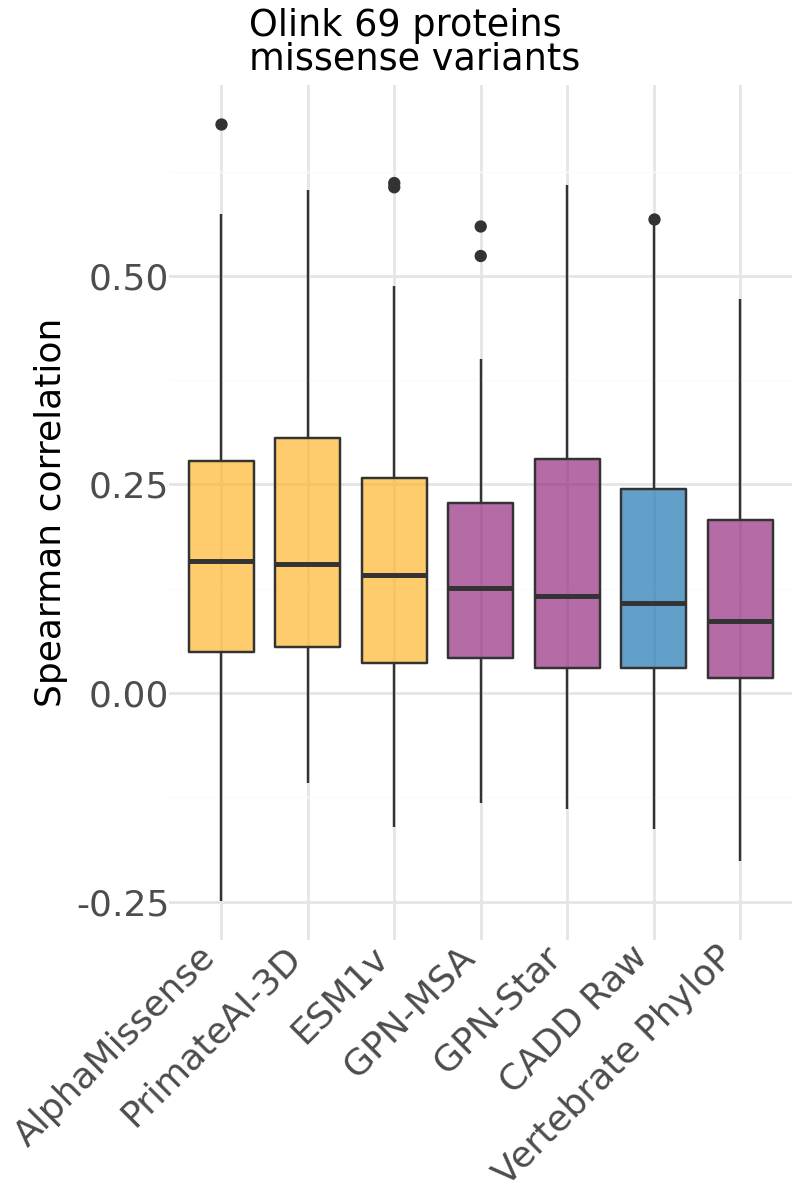

In [12]:
med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    # lims(
    #     y=(-0.1, 0.3)
    # ) +
    labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pd['region'].unique())} proteins \
            \nmissense variants"
            # \nGene body ±5kb"
            # \nTSS [{min_range}bp, {max_range}bp]"
            # \nsplice donor/acceptor variants"
    ) +
    theme(
        figure_size=(4, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [11]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_487682/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""gpn_star_llr_calibrated_mean""","""verphylop""",69,371.0,5.6919e-7
"""verphylop""","""cadd_raw""",69,400.0,0.000001
"""gpn_score""","""gpn_star_llr_calibrated_mean""",69,519.0,0.000038
"""esmscoremissense""","""verphylop""",69,541.0,0.000067
"""gpn_score""","""verphylop""",69,773.0,0.009381
"""gpn_score""","""esmscoremissense""",69,834.0,0.02554
